# Random Measure Stochastic Optimal Transport: Convergence Demonstrations

This notebook accompanies sections 4 and 5 of *Random Measure Stochastic Optimal Transport* (Passeggeri, Shenoy, Ye).

We demonstrate:
1. **Section 4.2** – Empirical convergence of the Wasserstein distance, pointwise (a.s.) and in the metric $d$
2. **Section 4.4–4.5** – Convergence for mollified empirical measures (resolving the curse of dimensionality)
3. **Section 4.5** – Wasserstein gradient flow convergence as more data is accumulated
4. **Section 5.2–5.3** – Bayesian consistency: posterior distance convergence and gradient flow convergence

**Setup:** Install dependencies with `pip install POT scipy numpy matplotlib`

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, multivariate_normal
from scipy.special import logsumexp
import ot  # POT: Python Optimal Transport
from tqdm import tqdm

# BG     = '#F7F4EF'   # warm off-white background
BG     = '#FFFFFF'   # white background

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'font.family':      'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        False,
})

rng = np.random.default_rng(13)
plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})

---
## Helper: Computing $W_2$ between empirical/continuous measures

We work in $d=1$ and $d=2$.  
In 1D, $W_2^2(\mu_n, \mu) = \int_0^1 |F_n^{-1}(u) - F^{-1}(u)|^2\,du$ (Theorem A.2 in the paper).  
In higher dimensions we use POT's `ot.emd2` (discrete–discrete) or `ot.sliced_wasserstein_distance`.

In [59]:
def w2_empirical_1d(samples, mu_ppf, n_quantiles=2000):
    """W_2 between empirical measure of `samples` and a 1D population
    given by its quantile function `mu_ppf`, via the quantile formula."""
    u = np.linspace(0, 1, n_quantiles + 2)[1:-1]
    q_pop = mu_ppf(u)                          # population quantiles
    q_emp = np.quantile(samples, u)            # empirical quantiles
    return np.sqrt(np.mean((q_emp - q_pop)**2))


def w2_discrete_nd(X, Y):
    """W_2 between two equal-weight point clouds X, Y in R^d via POT."""
    n, m = len(X), len(Y)
    a, b = np.ones(n) / n, np.ones(m) / m
    M = ot.dist(X, Y, metric='sqeuclidean')
    return np.sqrt(ot.emd2(a, b, M))


def w2_mollified_to_population_1d(samples, sigma, mu_ppf, n_quantiles=2000):
    """
    W_2 between the mollified empirical measure mu^sigma_n and the population mu.
    Uses the decomposition: W_2(mu^sigma_n, mu) <= W_2(mu^sigma_n, mu^sigma) + W_2(mu^sigma, mu)
    We approximate W_2(mu^sigma_n, mu^sigma) by drawing many samples from the mollified
    measure (each original sample + Gaussian noise) and comparing quantiles.
    """
    # Mollified empirical: each X_i + N(0, sigma^2)
    noise = rng.normal(0, sigma, size=len(samples))
    mollified = samples + noise
    # Smoothed population: mu * N(0, sigma^2); we draw samples from it
    # For a Gaussian population N(mu0, sig0^2), mu^sigma ~ N(mu0, sig0^2 + sigma^2)
    # We instead estimate W_2 numerically via quantiles:
    return w2_empirical_1d(mollified, mu_ppf)

---
## 1. Empirical Convergence of $W_2$ (Section 4.2)

**Setting:** $\mu = N(0,1)$ in $d=1$.

**Theorem 4.2 (LLN in $L^2_W$):**
- (a) $W_2(\hat\mu_n(\omega), \mu) \to 0$ for $\mathbf{P}$-a.e. $\omega$
- (b) $d(\hat\mu_n, \mu) \to 0$

**Theorem 4.3 (Fournier-Guillin):** In $d=1$, $d^2(\hat\mu_n, \mu) \lesssim n^{-1/2}$.

We plot:
- Several independent realisations of $W_2(\hat\mu_n(\omega), \mu)$ vs $n$ (pointwise a.s.)
- The mean $d(\hat\mu_n, \mu)$ over realisations with the $n^{-1/4}$ Fournier-Guillin envelope

In [60]:
# Population: N(0,1)
mu_ppf = norm(0, 1).ppf

sample_sizes = np.unique(np.round(np.logspace(1, 4, 30)).astype(int))
n_realisations = 40

# Shape: (n_realisations, len(sample_sizes))
W2_matrix = np.zeros((n_realisations, len(sample_sizes)))

for j, n in tqdm(enumerate(sample_sizes)):
    for r in range(n_realisations):
        samples = rng.standard_normal(n)
        W2_matrix[r, j] = w2_empirical_1d(samples, mu_ppf)

d_mean  = W2_matrix.mean(axis=0)        # approximates d(mu_n, mu)
d_std   = W2_matrix.std(axis=0)

# Fournier-Guillin rate: d^2 ~ C * n^{-1/2} in d=1  =>  d ~ C * n^{-1/4}
C_fg = d_mean[0] * sample_sizes[0]**0.25
fg_envelope = C_fg * sample_sizes**(-0.25)

30it [00:12,  2.37it/s] 


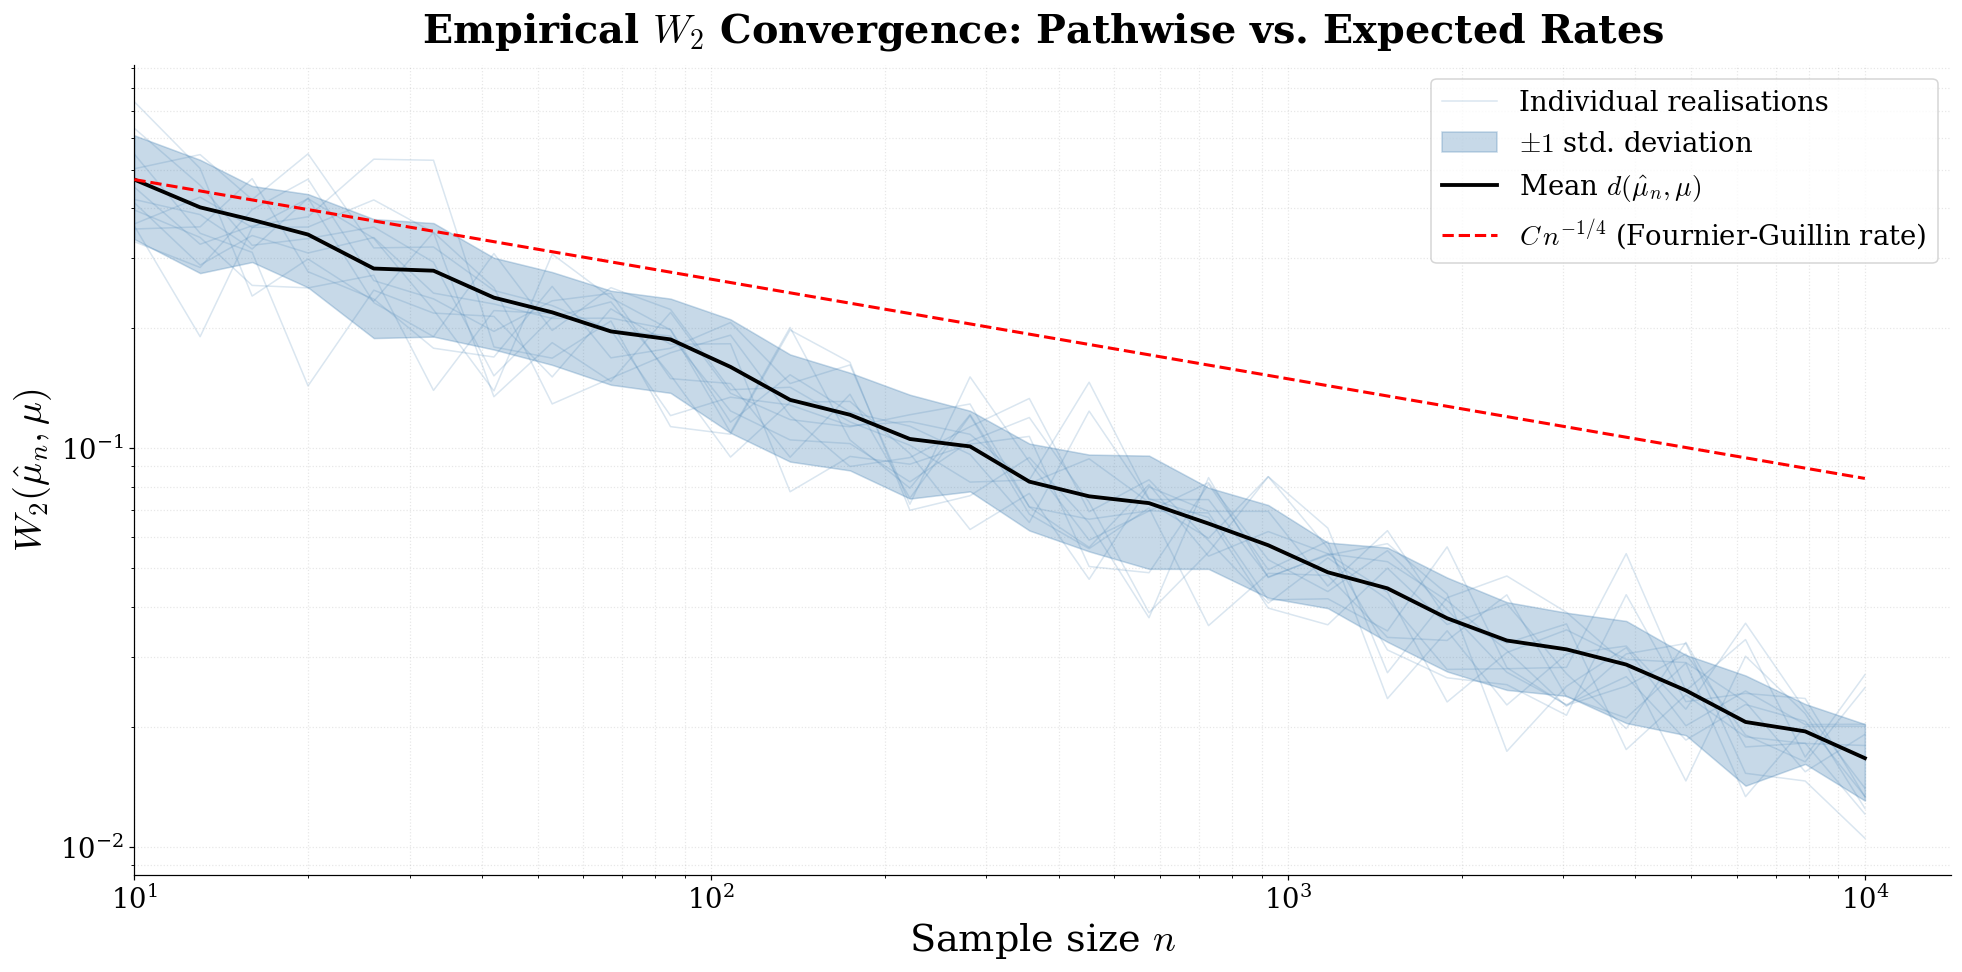

In [153]:
fig, ax = plt.subplots(1, 1, figsize=(18, 9), facecolor=BG)

for r in range(min(12, n_realisations)):
    label = 'Individual realisations' if r == 0 else None
    ax.loglog(sample_sizes, W2_matrix[r], color='steelblue', alpha=0.2, lw=1, zorder=1, label=label)

ax.fill_between(sample_sizes,
                np.maximum(d_mean - d_std, 1e-4),
                d_mean + d_std,
                alpha=0.3, color='steelblue', label=r'$\pm 1$ std. deviation', zorder=2)

ax.loglog(sample_sizes, d_mean, 'k-', lw=2.5, label=r'Mean $d(\hat{\mu}_n, \mu)$', zorder=4)

ax.loglog(sample_sizes, fg_envelope, 'r--', lw=2, label=r'$C\,n^{-1/4}$ (Fournier-Guillin rate)', zorder=5)

ax.set_xlabel('Sample size $n$', fontsize=25)
ax.set_ylabel(r'$W_2(\hat{\mu}_n, \mu)$', fontsize=25)
ax.set_title(r'Empirical $W_2$ Convergence: Pathwise vs. Expected Rates', fontsize=26, fontweight='bold', pad=15)

ax.set_xlim(left=min(sample_sizes))

ax.legend(fontsize=18, loc='upper right', frameon=True, facecolor='white', framealpha=0.8)
ax.grid(True, which='both', alpha=0.3, ls=':')
ax.tick_params(axis='both', which='major', labelsize=18)

for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_1_empirical_W2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Mollified Empirical Measures (Section 4.4)

**Proposition 4.14:** For bandwidth $\sigma(n) \to 0$ with $\sqrt{n}\,\sigma(n) \to \infty$,
$$d^2(\hat\mu^{\sigma(n)}_n, \mu) \lesssim \frac{C}{n} + d\,\sigma(n)^2.$$

Choosing $\sigma(n) = n^{-1/2}$ gives the **parametric rate** $O(n^{-1})$, strictly better than the un-smoothed Fournier-Guillin rate $n^{-2/d}$ in high dimensions.

We compare:
- $d(\hat\mu_n, \mu)$ (raw empirical, Fournier-Guillin limited)
- $d(\hat\mu^\sigma_n, \mu)$ with $\sigma = n^{-1/2}$ (mollified, parametric rate)
- $d(\hat\mu^\sigma_n, \mu)$ with a fixed large $\sigma$ (too much bias)

In [62]:
mu_ppf = norm(0, 1).ppf
sample_sizes_m = np.unique(np.round(np.logspace(1, 4.5, 25)).astype(int))
n_rep_m = 30

raw_means, moll_opt_means, moll_large_means = [], [], []

for n in tqdm(sample_sizes_m):
    raw_w2s, moll_opt_w2s, moll_large_w2s = [], [], []
    for _ in range(n_rep_m):
        samples = rng.standard_normal(n)
        # Raw
        raw_w2s.append(w2_empirical_1d(samples, mu_ppf))
        # Mollified, optimal bw sigma = n^{-1/2}
        sigma_opt = n**(-0.5)
        moll_opt_w2s.append(w2_empirical_1d(samples + rng.normal(0, sigma_opt, n), mu_ppf))
        # Mollified, fixed large bw
        sigma_large = 0.5
        moll_large_w2s.append(w2_empirical_1d(samples + rng.normal(0, sigma_large, n), mu_ppf))
    raw_means.append(np.mean(raw_w2s))
    moll_opt_means.append(np.mean(moll_opt_w2s))
    moll_large_means.append(np.mean(moll_large_w2s))

raw_means = np.array(raw_means)
moll_opt_means = np.array(moll_opt_means)
moll_large_means = np.array(moll_large_means)

100%|██████████| 25/25 [00:13<00:00,  1.89it/s]


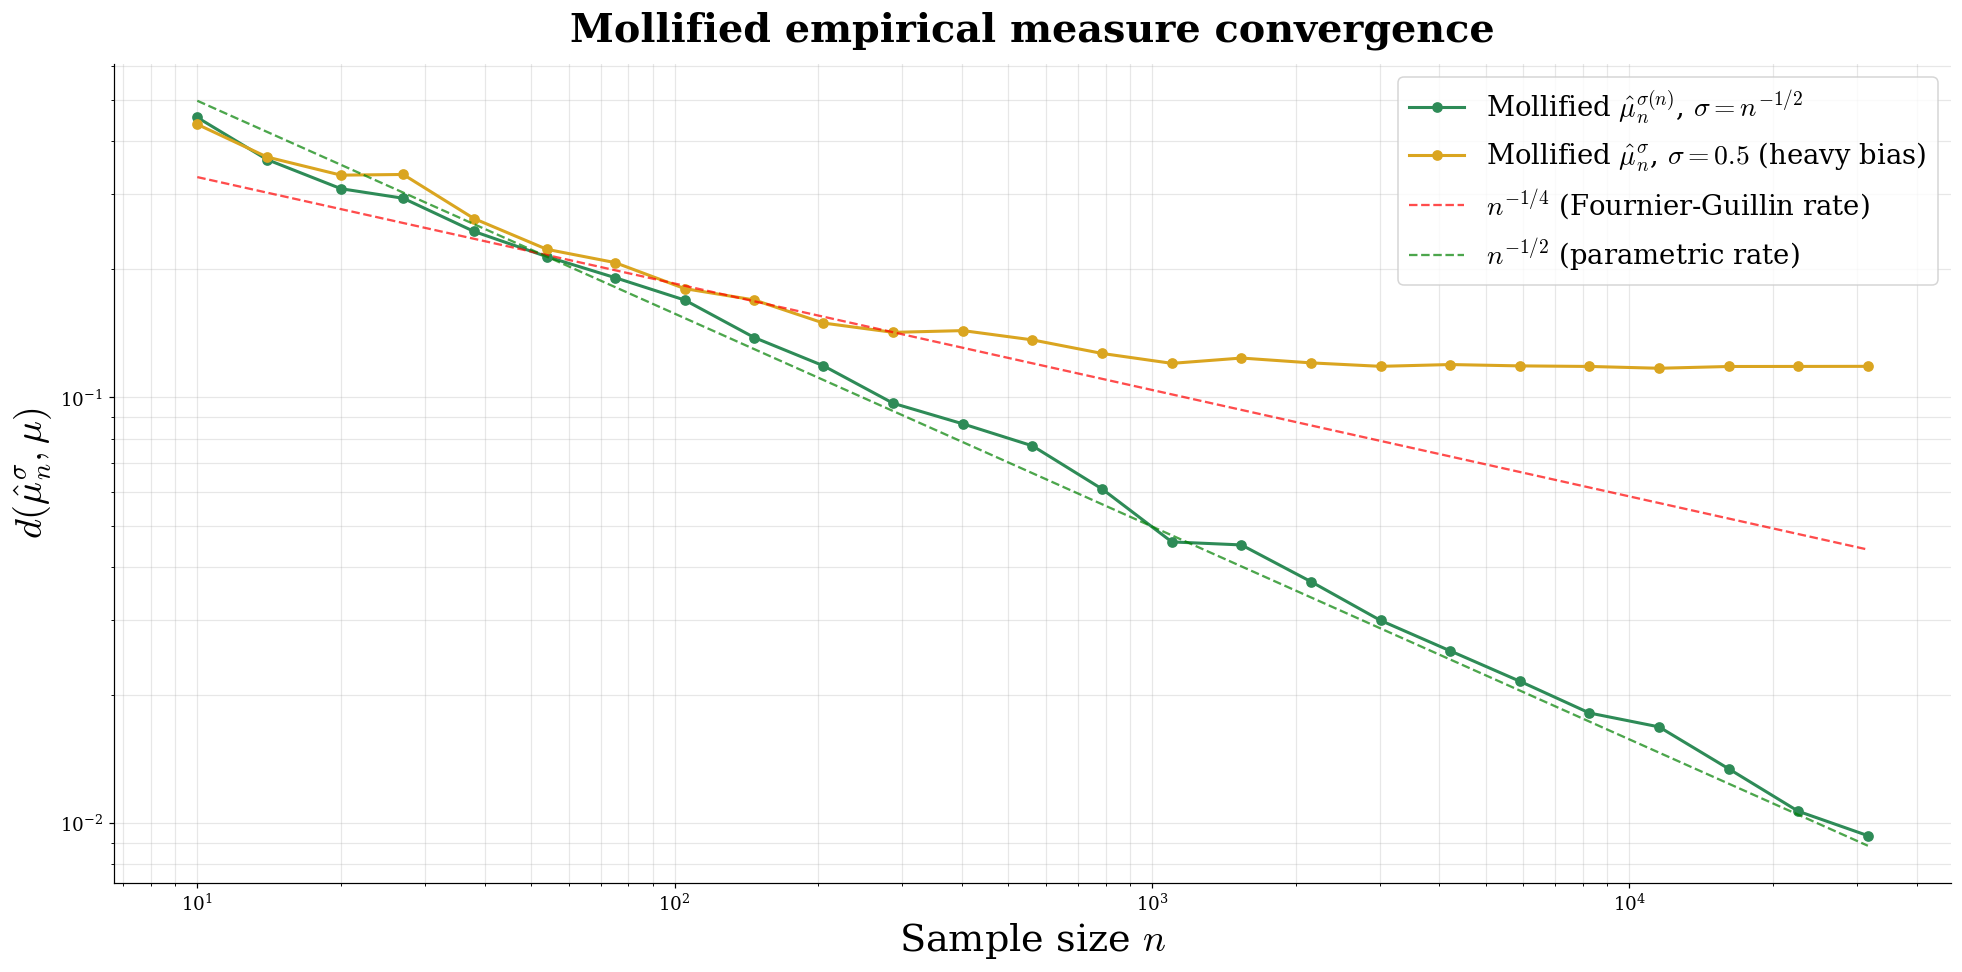

In [154]:

fig, ax = plt.subplots(figsize=(18, 9))
ax.loglog(sample_sizes_m, moll_opt_means, 'o-', color='seagreen', lw=2,
          label=r'Mollified $\hat{\mu}^{\sigma(n)}_n$, $\sigma=n^{-1/2}$')
ax.loglog(sample_sizes_m, moll_large_means, 'o-', color='goldenrod', lw=2,
          label=r'Mollified $\hat{\mu}^{\sigma}_n$, $\sigma=0.5$ (heavy bias)')

# Theoretical rates
C1 = raw_means[5] * sample_sizes_m[5]**0.25
ax.loglog(sample_sizes_m, C1 * sample_sizes_m**(-0.25), 'r--', alpha=0.7, label=r'$n^{-1/4}$ (Fournier-Guillin rate)')
C2 = moll_opt_means[5] * sample_sizes_m[5]**0.5
ax.loglog(sample_sizes_m, C2 * sample_sizes_m**(-0.5), 'g--', alpha=0.7, label=r'$n^{-1/2}$ (parametric rate)')

ax.set_xlabel('Sample size $n$', fontsize=25)
ax.set_ylabel(r'$d(\hat{\mu}_n^{\sigma}, \mu)$', fontsize = 25)
ax.set_title('Mollified empirical measure convergence', weight='bold', fontsize=26, pad=15)
ax.legend(fontsize=18)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_2_mollified.png', bbox_inches='tight')
plt.show()

---
## 3. Wasserstein Gradient Flow Convergence (Section 4.5)

**Proposition 4.18:** If $F$ is Wasserstein-$C^1$ with $L$-Lipschitz gradient, then
$$\sup_{t\in[0,T]} W_2(\mu^{n,\sigma(n)}_t(\omega),\, \mu_t) \le e^{Lt}\, W_2(\hat\mu^{\sigma(n)}_n(\omega),\, \mu_0).$$

**Setup:** We use the **Fokker-Planck / Ornstein-Uhlenbeck gradient flow**. Choose
$$F(\mu) = \text{KL}(\mu \| \pi) \quad \text{where } \pi = \mathcal{N}(0,1).$$
The gradient flow is $\partial_t \mu_t = \Delta\mu_t + \nabla\cdot(\mu_t \nabla V)$ with $V(x)=x^2/2$.  
In 1D, starting from $\mu_0 = \mathcal{N}(m_0, s_0^2)$ the solution is analytically tractable:
$$\mu_t = \mathcal{N}(m_0 e^{-t},\; 1 + (s_0^2-1)e^{-2t}).$$

We simulate the gradient flow by **discretising the continuity equation** on a particle level  
(Euler-Maruyama on the overdamped Langevin dynamics $dX_t = -\nabla V(X_t)\,dt + \sqrt{2}\,dW_t$,  
which gives the same Fokker-Planck). We then compare:
- Population flow (true $\mu_t$, analytic)
- Flow initialised at mollified empirical $\hat\mu^\sigma_n$ for growing $n$

In [65]:
# ---------------------------------------------------------------
# Population gradient flow: Fokker-Planck for F = KL(. || N(0,1))
# Starting from N(m0, s0^2), exact solution:
#   mu_t = N(m0*exp(-t), 1 + (s0^2-1)*exp(-2t))
# ---------------------------------------------------------------

m0, s0 = 3.0, 2.0   # initial distribution: N(3, 4)

def population_flow_params(t):
    """Returns (mean, std) of the population gradient flow at time t."""
    mean_t = m0 * np.exp(-t)
    var_t  = 1.0 + (s0**2 - 1.0) * np.exp(-2*t)
    return mean_t, np.sqrt(var_t)

def w2_gaussians(m1, s1, m2, s2):
    """W_2 between N(m1,s1^2) and N(m2,s2^2): closed form."""
    return np.sqrt((m1-m2)**2 + (s1-s2)**2)


def simulate_langevin_1d(x0, T=3.0, dt=0.01):
    """
    Euler-Maruyama for dX = -X dt + sqrt(2) dW  (OU process targeting N(0,1)).
    x0: initial particle positions, shape (n_particles,)
    Returns positions at each time step and time grid.
    """
    n_steps = int(T / dt)
    xs = [x0.copy()]
    x = x0.copy()
    for _ in range(n_steps):
        x = x - x * dt + np.sqrt(2 * dt) * rng.standard_normal(len(x))
        xs.append(x.copy())
    ts = np.linspace(0, T, n_steps + 1)
    return np.array(xs), ts

In [66]:
# Simulate gradient flows for different n
T = 3.0
dt = 0.02
n_particles = 2000  # always use many particles so particle error is negligible
n_list = [20, 100, 500, 2000]

ts = np.arange(0, T + dt, dt)

# True population flow (analytic)
pop_means = [population_flow_params(t)[0] for t in ts]
pop_stds  = [population_flow_params(t)[1] for t in ts]

# For each n: draw n samples from N(m0,s0^2), mollify with sigma=n^{-1/2},
# initialise n_particles from mollified empirical, run Langevin.
W2_trajectories = {}  # n -> array of W2(mu^{n,sigma}_t, mu_t)

n_omega = 20  # number of random realisations per n (to estimate d)

for n in n_list:
    sigma_n = n**(-0.5)
    W2_reals = np.zeros((n_omega, len(ts)))
    for r in tqdm(range(n_omega)):
        # Draw n samples from mu0 = N(m0, s0^2)
        samples = rng.normal(m0, s0, n)
        # Mollify
        init_particles = np.repeat(
            samples + rng.normal(0, sigma_n, n),
            n_particles // n
        )[:n_particles]
        # Run Langevin from mollified empirical
        xs, _ = simulate_langevin_1d(init_particles, T=T, dt=dt)
        # W2 at each time step vs population flow (approximate via quantiles)
        for j, t in enumerate(ts):
            mt, st = population_flow_params(t)
            W2_reals[r, j] = w2_empirical_1d(xs[j], norm(mt, st).ppf)
    W2_trajectories[n] = W2_reals

print("Simulation complete.")

100%|██████████| 20/20 [00:26<00:00,  1.33s/it]

Simulation complete.


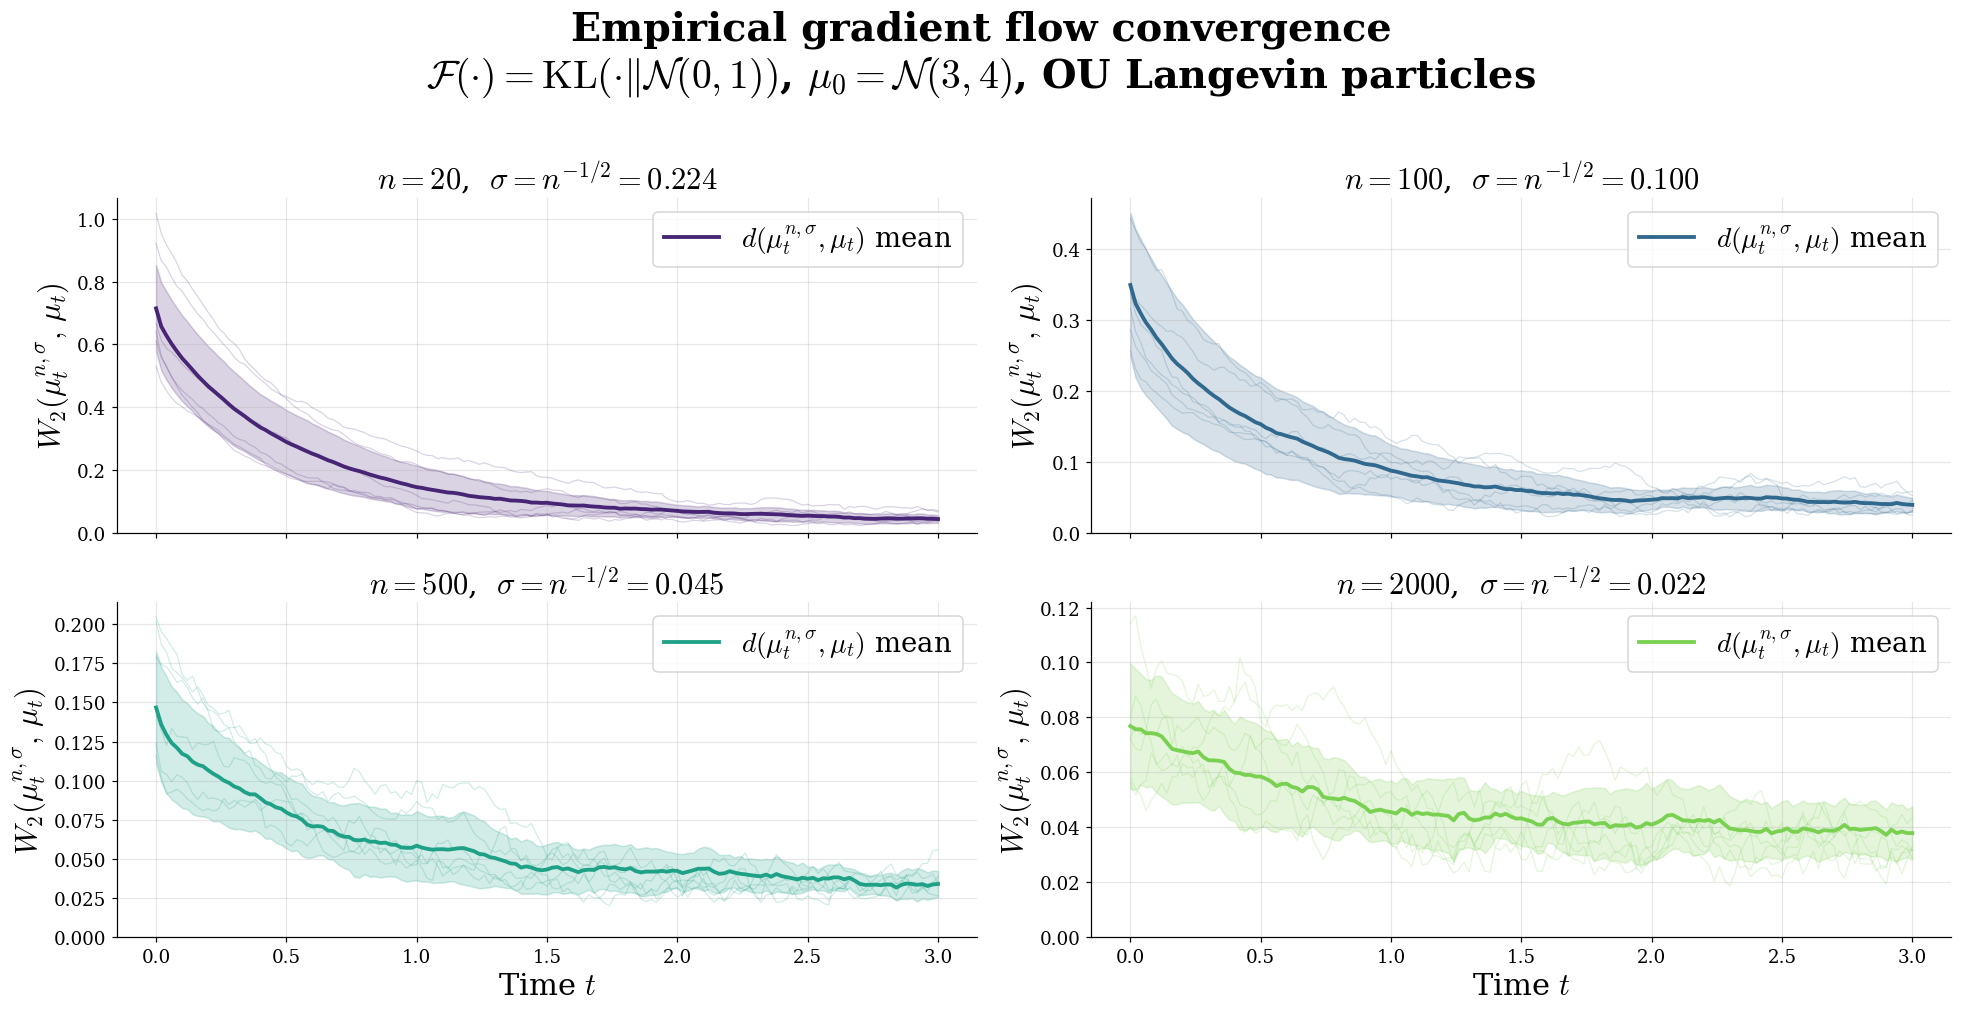

In [155]:
# For OU: the Wasserstein gradient is Lipschitz with L=1 (drift is linear)

fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex=True)
colors = plt.cm.viridis(np.linspace(0.1, 0.8, len(n_list)))

for ax, n, col in zip(axes.ravel(), n_list, colors):
    W2_mat = W2_trajectories[n]          # shape (n_omega, len(ts))
    W2_mean = W2_mat.mean(axis=0)
    W2_std  = W2_mat.std(axis=0)

    # Plot a few realisations
    for r in range(min(6, n_omega)):
        ax.plot(ts, W2_mat[r], color=col, alpha=0.2, lw=0.8)
    ax.plot(ts, W2_mean, color=col, lw=2.5,
            label=f'$d(\\mu^{{n,\\sigma}}_t,\\mu_t)$ mean')
    ax.fill_between(ts, np.maximum(W2_mean - W2_std, 0), W2_mean + W2_std,
                    color=col, alpha=0.2)

    ax.set_title(f'$n = {n}$,  $\\sigma = n^{{-1/2}} = {1/np.sqrt(n):.3f}$', fontsize=20)
    ax.set_ylabel(r'$W_2(\mu^{n,\sigma}_t,\, \mu_t)$', fontsize=20)
    ax.legend(fontsize=18)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

for ax in axes[1]:
    ax.set_xlabel('Time $t$', fontsize=20)

plt.suptitle('Empirical gradient flow convergence\n'
             r'$\mathcal{F}(\cdot)=\mathrm{KL}(\cdot\|\mathcal{N}(0,1))$, '
             r'$\mu_0=\mathcal{N}(3,4)$, OU Langevin particles',
             fontsize=26, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_3_gradient_flow.png', bbox_inches='tight')
plt.show()

---
## 4. Bayesian Analysis (Section 5)

### Gaussian conjugate prior

We consider the classical **normal-normal conjugate model**:
- True data-generating measure: $\pi = \mathcal{N}(\theta_0, \sigma_0^2)$ with $\theta_0 = 2,\, \sigma_0 = 1$
- Prior: $\theta \sim \mathcal{N}(0, \tau^2)$ with $\tau = 3$ (diffuse)
- We fix $\sigma_0^2 = 1$ known. After $n$ observations $X_1,\ldots,X_n \sim \mathcal{N}(\theta,1)$:

$$\theta \mid X_{1:n} \sim \mathcal{N}\!\left(\frac{n\bar{X}/\sigma_0^2}{n/\sigma_0^2 + 1/\tau^2},\; \frac{1}{n/\sigma_0^2 + 1/\tau^2}\right)$$

The posterior **random measure** $\Pi_n$ is: for each $\omega$, draw $\theta^\omega \sim$ posterior, then $\Pi_n(\omega) = \mathcal{N}(\theta^\omega, 1)$.

**Proposition 5.7 (Wasserstein consistency):** $d(\Pi_n, \pi) \to 0$ a.s.

Since both the posterior realisations and truth are Gaussian, $W_2(\Pi_n(\omega), \pi)$ has a closed form:
$$W_2(\mathcal{N}(\theta^\omega, 1),\; \mathcal{N}(\theta_0, 1)) = |\theta^\omega - \theta_0|.$$
So $d(\Pi_n, \pi) = \mathbb{E}[|\theta^\omega - \theta_0|^2]^{1/2} = \text{(posterior RMSE for }\theta)$.

In [68]:
theta_0   = 2.0   # true parameter
sigma_0   = 1.0   # known noise std
tau       = 3.0   # prior std

def posterior_params(X_obs, sigma_0=sigma_0, tau=tau):
    """Gaussian conjugate posterior for theta given X_obs ~ N(theta, sigma_0^2)."""
    n = len(X_obs)
    xbar = X_obs.mean()
    precision_post = n / sigma_0**2 + 1 / tau**2
    mean_post = (n * xbar / sigma_0**2) / precision_post
    std_post  = 1.0 / np.sqrt(precision_post)
    return mean_post, std_post

# d(Pi_n, pi) = E_omega[ W_2^2(Pi_n(omega), pi) ]^{1/2}
#             = E_omega[ (theta^omega - theta_0)^2 ]^{1/2}
#             = sqrt( (m_n - theta_0)^2 + s_n^2 )   [since theta^omega ~ N(m_n, s_n^2)]
def d_posterior_to_truth(mean_post, std_post, theta_0=theta_0):
    return np.sqrt((mean_post - theta_0)**2 + std_post**2)

sample_sizes_bayes = np.unique(np.round(np.logspace(0.5, 3.5, 30)).astype(int))
n_datasets = 80   # number of independent datasets (realisations of the data)

d_bayes_matrix = np.zeros((n_datasets, len(sample_sizes_bayes)))

for k, n in enumerate(tqdm(sample_sizes_bayes)):
    for r in range(n_datasets):
        X_obs = rng.normal(theta_0, sigma_0, n)
        m_n, s_n = posterior_params(X_obs)
        d_bayes_matrix[r, k] = d_posterior_to_truth(m_n, s_n)

d_bayes_mean = d_bayes_matrix.mean(axis=0)
d_bayes_std  = d_bayes_matrix.std(axis=0)

# Theoretical rate: posterior std ~ n^{-1/2}, bias -> 0 => d ~ n^{-1/2}
C_b = d_bayes_mean[5] * sample_sizes_bayes[5]**0.5

100%|██████████| 30/30 [00:00<00:00, 997.08it/s]


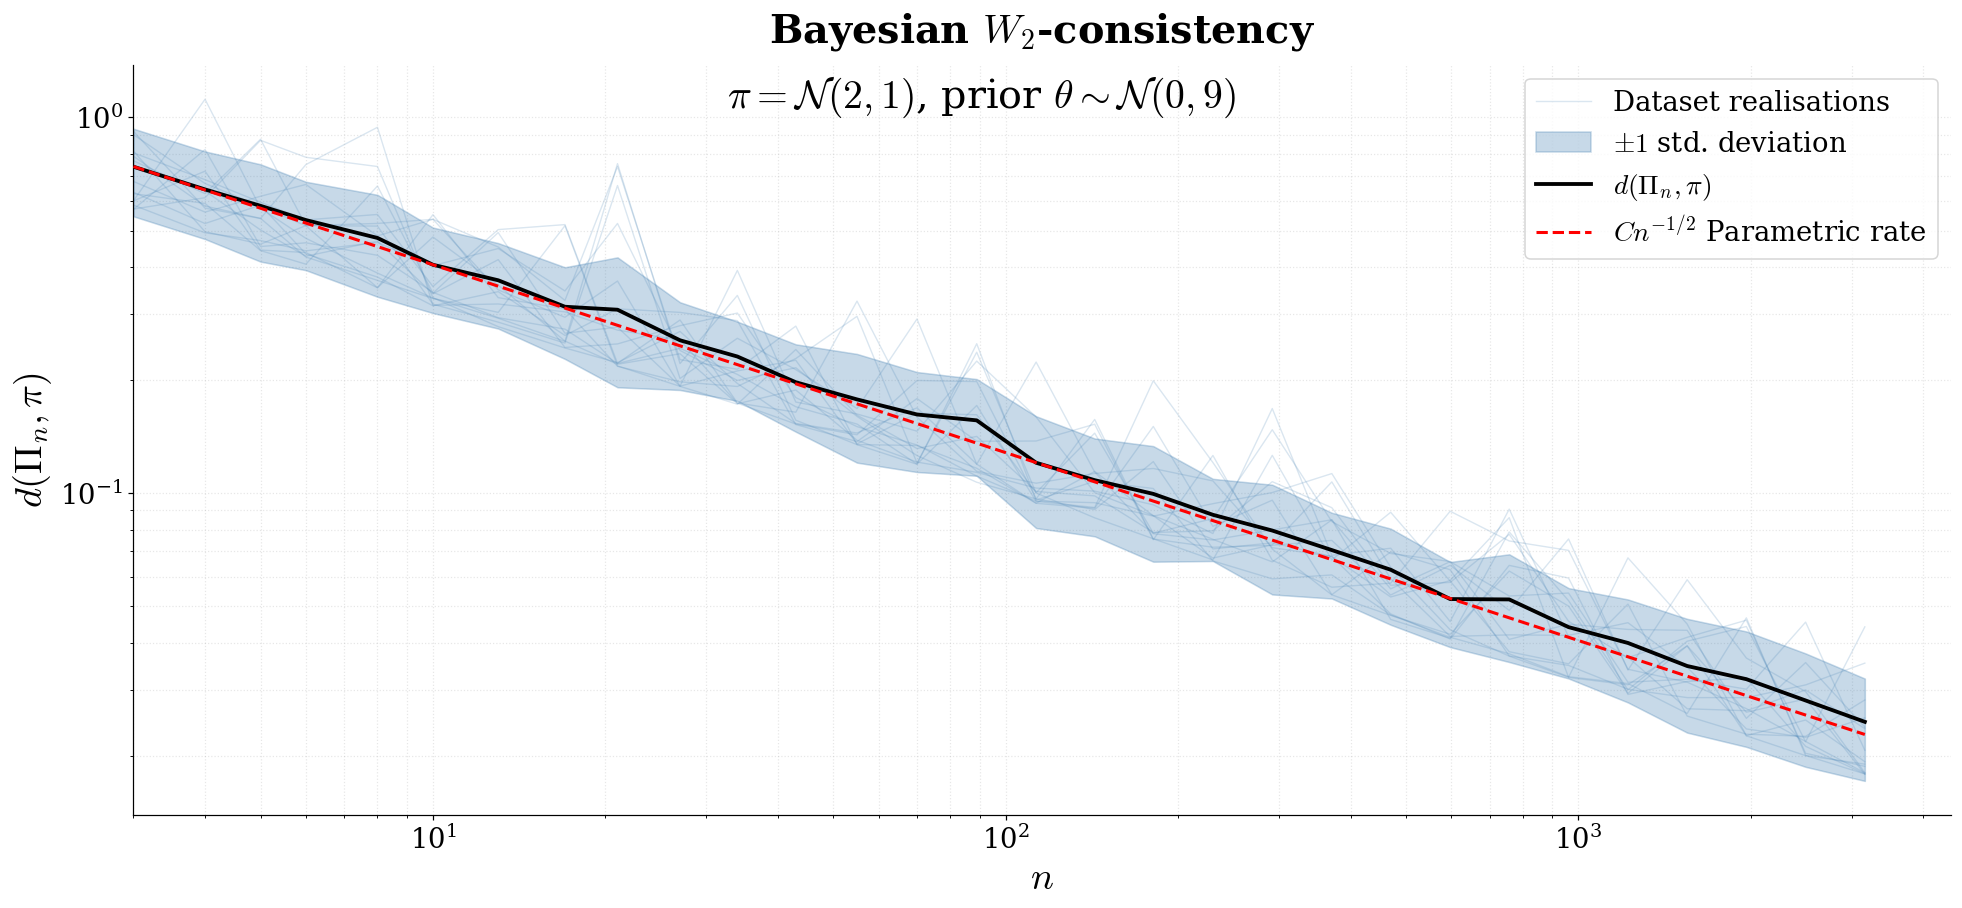

In [156]:
fig, ax = plt.subplots(1, 1, figsize=(18, 9), facecolor=BG)

for r in range(min(15, n_datasets)):
    label = 'Dataset realisations' if r == 0 else None
    ax.loglog(sample_sizes_bayes, d_bayes_matrix[r], color='steelblue', alpha=0.2, lw=0.9, zorder=1, label=label)

ax.fill_between(sample_sizes_bayes,
                np.maximum(d_bayes_mean - d_bayes_std, 1e-4),
                d_bayes_mean + d_bayes_std,
                alpha=0.3, color='steelblue', label=r'$\pm 1$ std. deviation', zorder=2)

ax.loglog(sample_sizes_bayes, d_bayes_mean, 'k-', lw=2.5, label=r'$d(\Pi_n, \pi)$', zorder=4)

ax.loglog(sample_sizes_bayes, C_b * sample_sizes_bayes**(-0.5), 'r--', lw=2, label=r'$C n^{-1/2}$ Parametric rate', zorder=5)

ax.set_xlabel('$n$', fontsize=25)
ax.set_ylabel(r'$d(\Pi_n, \pi)$', fontsize=25)
ax.set_title(r'Bayesian $W_2$-consistency', fontsize=26, fontweight='bold', pad=15)

ax.set_xlim(left=min(sample_sizes_bayes))

ax.legend(fontsize=18, loc='upper right', frameon=True, facecolor='white', framealpha=0.8)
ax.grid(True, which='both', alpha=0.3, ls=':')
ax.tick_params(axis='both', which='major', labelsize=18)

for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

plt.suptitle(r'$\pi=\mathcal{N}(2,1)$, prior $\theta\sim\mathcal{N}(0,9)$', fontsize=26, y=0.85)
plt.tight_layout()
plt.savefig('fig5_1_bayesian_w2.png', dpi=150, bbox_inches='tight')
plt.show()

### Bayesian Posterior Concentration (Schwartz)

Proposition 5.7 also asserts that the **posterior mass on $W_2$-balls shrinks** to concentrate at $\pi$.  
Here we plot $\Pi_n(\{\mu : W_2(\mu, \pi) > \varepsilon\})$ for varying $n$ and $\varepsilon$.

4it [00:00, 188.54it/s]


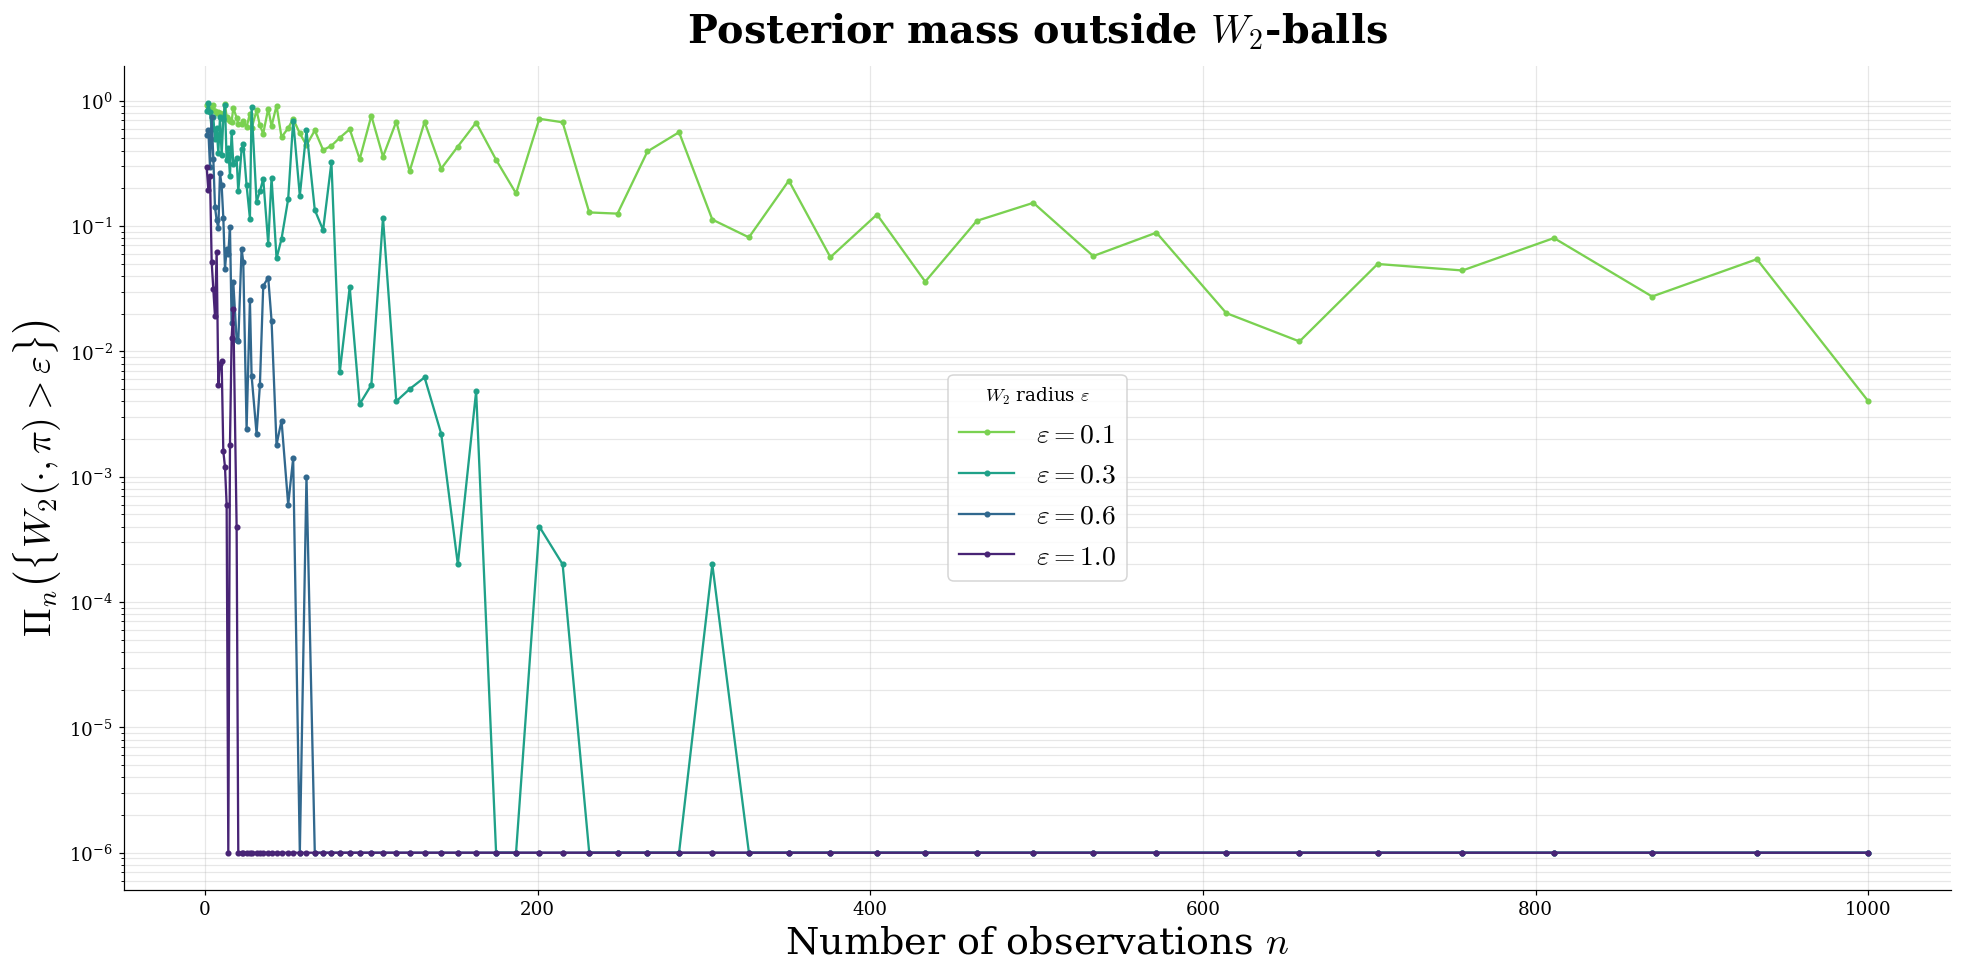

In [157]:
epsilons = [0.1, 0.3, 0.6, 1.0]
ns_conc = np.unique(np.round(np.logspace(0, 3, 100)).astype(int))
n_mc = 5000  # MC samples from posterior to estimate tail probability

fig, ax = plt.subplots(figsize=(18, 9))
colors_eps = plt.cm.viridis(np.linspace(0.8, 0.1, len(epsilons)))

for eps, col in tqdm(zip(epsilons, colors_eps)):
    tail_probs = []
    for n in ns_conc:
        X_obs = rng.normal(theta_0, sigma_0, n)
        m_n, s_n = posterior_params(X_obs)
        # Posterior draw theta^omega ~ N(m_n, s_n^2)
        theta_draws = rng.normal(m_n, s_n, n_mc)
        # W_2(N(theta^omega,1), N(theta_0,1)) = |theta^omega - theta_0|
        w2_draws = np.abs(theta_draws - theta_0)
        tail_probs.append(np.mean(w2_draws > eps))
    ax.semilogy(ns_conc, np.maximum(tail_probs, 1e-6), '-o', color=col, ms=3, lw=1.5,
                label=rf'$\varepsilon = {eps}$')

ax.set_xlabel('Number of observations $n$', fontsize=25)
ax.set_ylabel(r'$\Pi_n\left(\{W_2(\cdot, \pi) > \varepsilon\}\right)$', fontsize=25)
ax.set_title('Posterior mass outside $W_2$-balls', fontsize=26, fontweight='bold', pad=15)
ax.legend(title='$W_2$ radius $\\varepsilon$', fontsize=18)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_2_schwartz.png', bbox_inches='tight')
plt.show()

### Bayesian Gradient Flow Convergence

**Proposition 5.11:** With the Bayesian posterior as initialisation,
$$\sup_{t\in[0,T]} W_2(\Pi_{n,t}(\omega),\, \pi_t) \le e^{Lt}\,W_2(\Pi_{n,0}(\omega),\, \pi_0)$$
and $\sup_t d(\Pi_{n,t}, \pi_t) \to 0$ as $n\to\infty$.

**Setup:** Same as §3 but now we **initialise the gradient flow from posterior draws** rather than from  
the mollified empirical. The target is still $\mathcal{N}(0,1)$. The true initial measure is $\pi_0 = \mathcal{N}(\theta_0, 1)$.
Each realisation $\omega$ draws $\theta^\omega$ from the posterior and runs Langevin from $\mathcal{N}(\theta^\omega, 1)$.

Key difference from §3: **no mollification needed** (posterior realisations are already a.c.).

In [99]:
def w2_empirical_1d(samples, mu_ppf, n_quantiles=2000):
    u     = np.linspace(0, 1, n_quantiles + 2)[1:-1]
    q_pop = mu_ppf(u)
    q_emp = np.quantile(samples, u)
    return np.sqrt(np.mean((q_emp - q_pop)**2))

def simulate_langevin_1d(x0, T=3.0, dt=0.01):
    """Euler-Maruyama for dX = -X dt + sqrt(2) dW  (OU targeting N(0,1))."""
    n_steps = int(T / dt)
    xs = [x0.copy()]
    x  = x0.copy()
    for _ in range(n_steps):
        x = x - x * dt + np.sqrt(2 * dt) * rng.standard_normal(len(x))
        xs.append(x.copy())
    return np.array(xs), np.linspace(0, T, n_steps + 1)

def posterior_params(X_obs, sigma_0=1.0, tau=3.0):
    n           = len(X_obs)
    xbar        = X_obs.mean()
    prec_post   = n / sigma_0**2 + 1 / tau**2
    mean_post   = (n * xbar / sigma_0**2) / prec_post
    std_post    = 1.0 / np.sqrt(prec_post)
    return mean_post, std_post

# ── experiment parameters ────────────────────────────────────────
theta_0      = 1
sigma_0      = 1.0
T_bay        = 3.0
dt_bay       = 0.02
n_particles  = 1000
n_list_bay   = [5, 20, 100, 500]
n_omega_bay  = 20
ts_bay       = np.arange(0, T_bay + dt_bay, dt_bay)

def bayes_pop_flow_params(t):
    """Population flow mu_t = N(theta_0 * exp(-t), 1)."""
    return theta_0 * np.exp(-t), 1.0

# Closed-form W2(pi_t, N(0,1)): both Gaussians have std=1,
# so W2 = |mean(t) - 0| = theta_0 * exp(-t)
w2_pop_to_target = theta_0 * np.exp(-ts_bay)

In [100]:
W2_flow_traj = {}   # existing quantity
W2_tgt_traj  = {}   # new quantity

target_ppf = norm(0, 1).ppf   # quantile function of N(0,1)

posterior_params_used = {}

for n in n_list_bay:
    flow_mat = np.zeros((n_omega_bay, len(ts_bay)))
    tgt_mat  = np.zeros((n_omega_bay, len(ts_bay)))

    X_obs        = rng.normal(theta_0, sigma_0, n)
    m_n, s_n     = posterior_params(X_obs)
    posterior_params_used[n] = (m_n, s_n)   # save these

    for r in tqdm(range(n_omega_bay)):
        theta_r = rng.normal(m_n, s_n)
        x0      = rng.normal(theta_r, 1.0, n_particles)
        xs, _   = simulate_langevin_1d(x0, T=T_bay, dt=dt_bay)

        for j, t in enumerate(ts_bay):
            mt, st = bayes_pop_flow_params(t)
            # distance to population flow
            flow_mat[r, j] = w2_empirical_1d(xs[j], norm(mt, st).ppf)
            # distance to stationary target N(0,1)
            tgt_mat[r, j]  = w2_empirical_1d(xs[j], target_ppf)

    W2_flow_traj[n] = flow_mat
    W2_tgt_traj[n]  = tgt_mat
    print(f"n={n} done")

print("Simulation complete.")

100%|██████████| 20/20 [00:13<00:00,  1.52it/s]


n=5 done


100%|██████████| 20/20 [00:12<00:00,  1.58it/s]


n=20 done


100%|██████████| 20/20 [00:13<00:00,  1.53it/s]


n=100 done


100%|██████████| 20/20 [00:13<00:00,  1.51it/s]

n=500 done
Simulation complete.


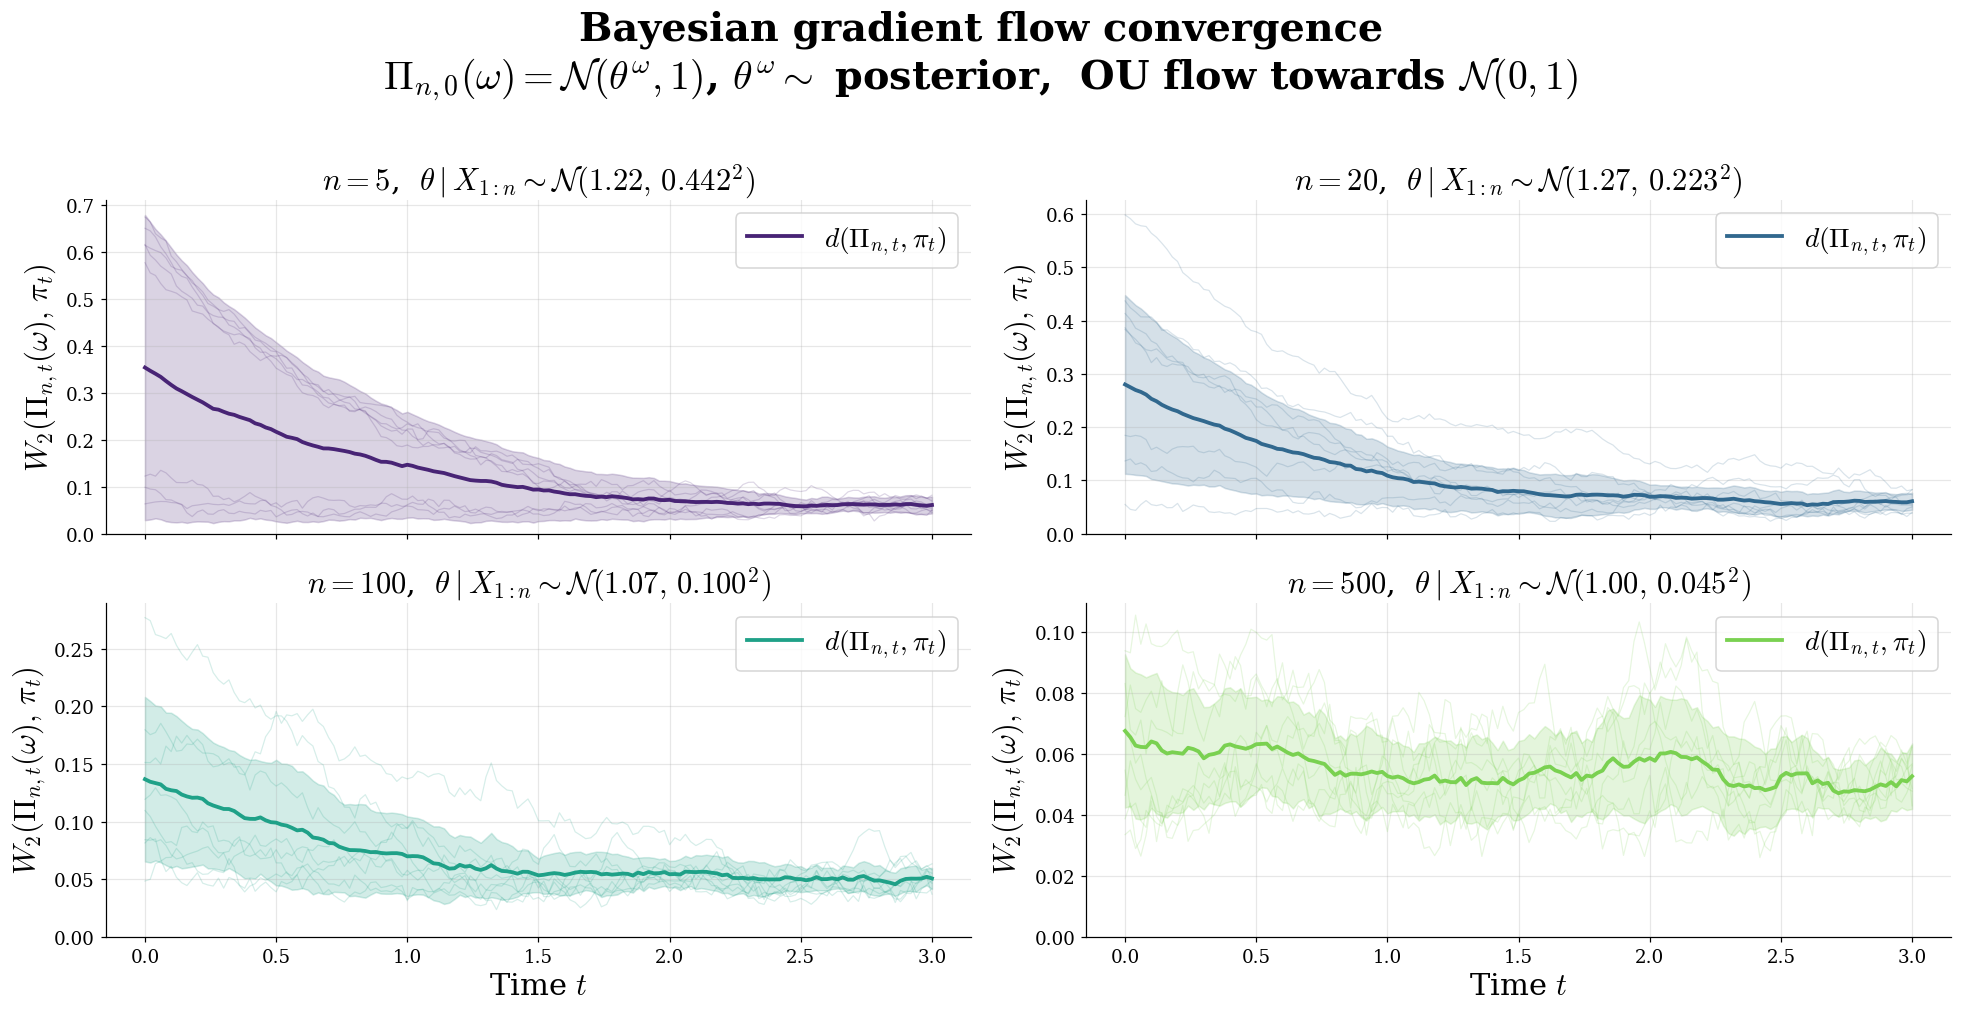

In [158]:
colors_bay = plt.cm.viridis(np.linspace(0.1, 0.8, len(n_list_bay)))

fig1, axes1 = plt.subplots(2, 2, figsize=(18, 9), sharex=True)

for ax, n, col in zip(axes1.ravel(), n_list_bay, colors_bay):
    W2_mat   = W2_flow_traj[n]
    W2_mean  = W2_mat.mean(axis=0)
    W2_std   = W2_mat.std(axis=0)

    for r in range(min(8, n_omega_bay)):
        ax.plot(ts_bay, W2_mat[r], color=col, alpha=0.18, lw=0.8)
    ax.plot(ts_bay, W2_mean, color=col, lw=2.5,
            label=r'$d(\Pi_{n,t}, \pi_t)$')
    ax.fill_between(ts_bay,
                    np.maximum(W2_mean - W2_std, 0),
                    W2_mean + W2_std,
                    color=col, alpha=0.2)

    X_obs_ref    = rng.normal(theta_0, sigma_0, n)
    _, s_n_ref   = posterior_params(X_obs_ref)
    m_n_used, s_n_used = posterior_params_used[n]
    ax.set_title(
        f'$n = {n}$,  '
        f'$\\theta \\mid X_{{1:n}} \\sim \\mathcal{{N}}'
        f'({m_n_used:.2f},\\, {s_n_used:.3f}^2)$', fontsize=20
    )
    ax.set_ylabel(r'$W_2(\Pi_{n,t}(\omega),\, \pi_t)$', fontsize=20)
    ax.legend(fontsize=18)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

for ax in axes1[1]:
    ax.set_xlabel('Time $t$', fontsize=20)

fig1.suptitle(
    'Bayesian gradient flow convergence\n'
    r'$\Pi_{n,0}(\omega) = \mathcal{N}(\theta^\omega, 1)$, '
    r'$\theta^\omega \sim$ posterior,  OU flow towards $\mathcal{N}(0,1)$',
    fontsize=26, weight='bold', y=1.02)
fig1.tight_layout()
fig1.savefig('fig5_3_bayesian_flow.png', bbox_inches='tight')
plt.show()

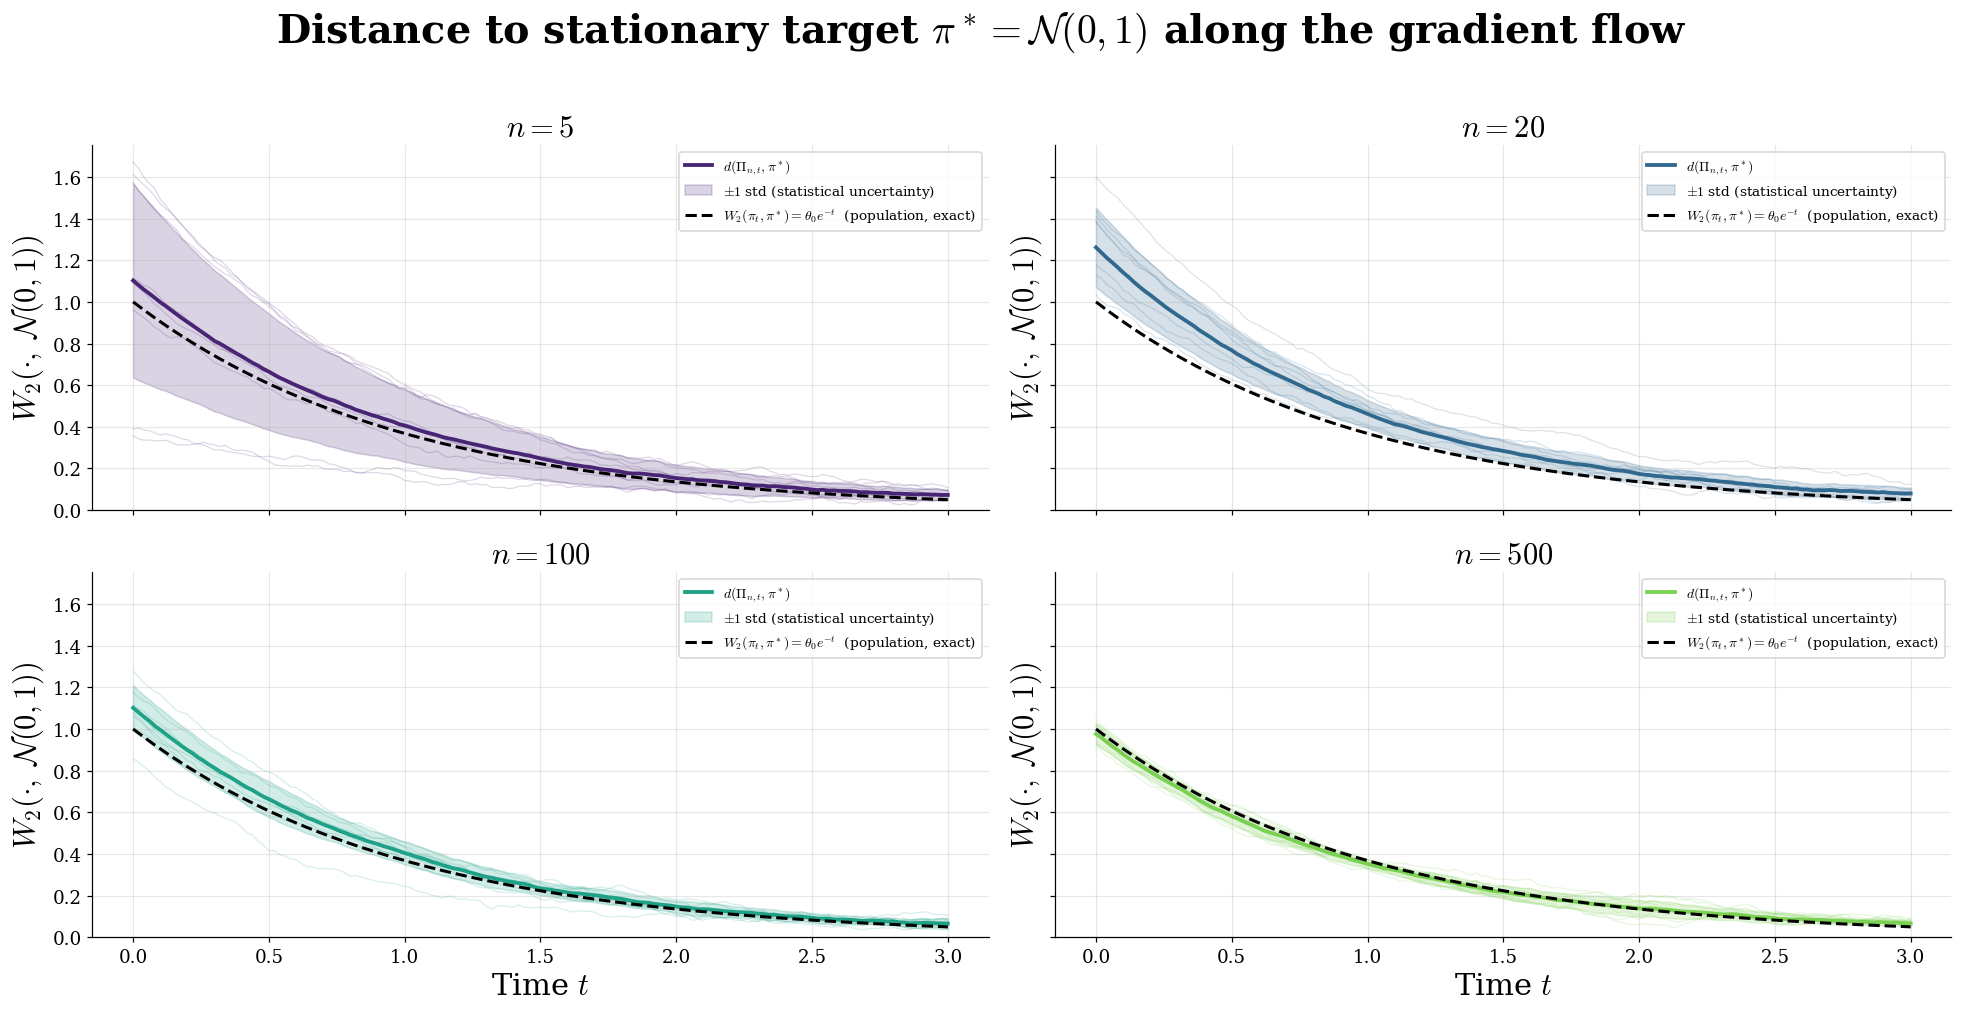

In [159]:
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 9), sharex=True, sharey=True)

for ax, n, col in zip(axes2.ravel(), n_list_bay, colors_bay):
    W2_mat  = W2_tgt_traj[n]
    W2_mean = W2_mat.mean(axis=0)
    W2_std  = W2_mat.std(axis=0)

    # individual realisations
    for r in range(min(8, n_omega_bay)):
        ax.plot(ts_bay, W2_mat[r], color=col, alpha=0.18, lw=0.8)

    # mean ± std band
    ax.plot(ts_bay, W2_mean, color=col, lw=2.5,
            label=r'$d(\Pi_{n,t}, \pi^*)$')
    ax.fill_between(ts_bay,
                    np.maximum(W2_mean - W2_std, 0),
                    W2_mean + W2_std,
                    color=col, alpha=0.2,
                    label=r'$\pm 1$ std (statistical uncertainty)')

    # closed-form population distance-to-target (same in every panel)
    ax.plot(ts_bay, w2_pop_to_target, 'k--', lw=2.0,
            label=r'$W_2(\pi_t, \pi^*)=\theta_0 e^{-t}$  (population, exact)')

    # exponential decay reference line
    ax.set_title(f'$n = {n}$', fontsize=20)
    ax.set_ylabel(r'$W_2(\cdot,\; \mathcal{N}(0,1))$', fontsize=20)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

for ax in axes2[1]:
    ax.set_xlabel('Time $t$', fontsize=20)

fig2.suptitle(
    r'Distance to stationary target $\pi^* = \mathcal{N}(0,1)$ along the gradient flow',
    fontsize=26, weight='bold', y=1.02)
fig2.tight_layout()
fig2.savefig('fig5_4_distance_to_target.png', bbox_inches='tight')
plt.show()

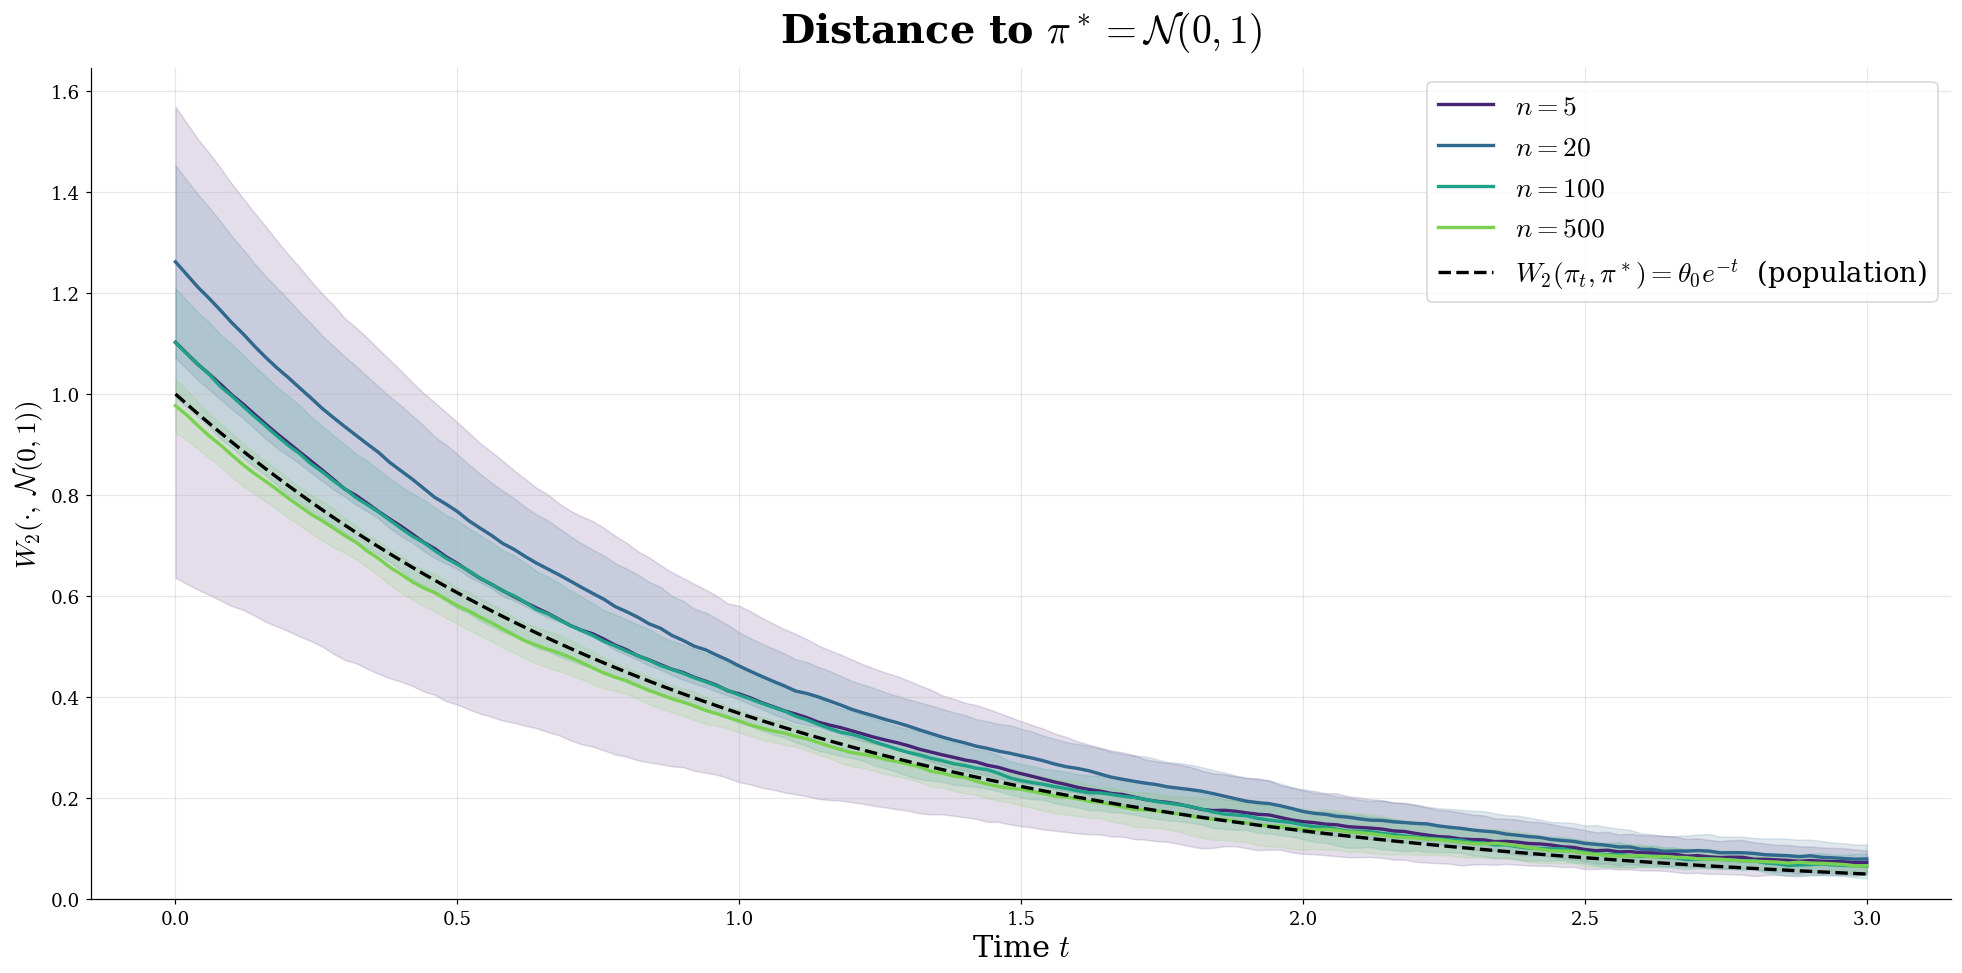

In [160]:
fig3, ax3 = plt.subplots(figsize=(18, 9))

for n, col in zip(n_list_bay, colors_bay):
    W2_mat  = W2_tgt_traj[n]
    W2_mean = W2_mat.mean(axis=0)
    W2_std  = W2_mat.std(axis=0)

    ax3.plot(ts_bay, W2_mean, color=col, lw=2.2, label=f'$n={n}$')
    ax3.fill_between(ts_bay,
                     np.maximum(W2_mean - W2_std, 0),
                     W2_mean + W2_std,
                     color=col, alpha=0.15)

ax3.plot(ts_bay, w2_pop_to_target, 'k--', lw=2.2,
         label=r'$W_2(\pi_t, \pi^*)=\theta_0 e^{-t}$  (population)')

ax3.set_xlabel('Time $t$', fontsize=20)
ax3.set_ylabel(r'$W_2(\cdot,\; \mathcal{N}(0,1))$', fontsize=18)
ax3.set_title(
    r'Distance to $\pi^* = \mathcal{N}(0,1)$',
    fontsize=26, weight='bold', y=1.02)
ax3.legend(fontsize=18, loc='upper right')
ax3.grid(alpha=0.3)
ax3.set_ylim(bottom=0)
fig3.tight_layout()
fig3.savefig('fig5_5_distance_to_target_overlay.png', bbox_inches='tight')
plt.show()